# FarmTech Solutions — Visão Computacional com YOLOv5
## Detecção de Milho e Tomate

Este notebook implementa um sistema de visão computacional utilizando YOLOv5
para detectar e classificar imagens de **milho** e **tomate**, simulando um
cenário real de uso na área do agronegócio.

As etapas seguidas foram:
1. Montagem e organização do dataset
2. Rotulação das imagens com Make Sense IA
3. Treinamento com 30 épocas
4. Treinamento com 60 épocas
5. Comparação dos resultados
6. Teste do modelo final

In [1]:
# Conectar ao Google Drive para acessar o dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Instalação do YOLOv5
Clonamos o repositório oficial do YOLOv5 e instalamos as dependências necessárias.

In [2]:
# Clonar o repositório oficial do YOLOv5
!git clone https://github.com/ultralytics/yolov5

# Entrar na pasta do YOLOv5
%cd yolov5

# Instalar as dependências necessárias
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17924, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 17924 (delta 53), reused 15 (delta 15), pack-reused 17855 (from 5)
Receiving objects: 100% (17924/17924), 17.06 MiB | 21.33 MiB/s, done.
Resolving deltas: 100% (12204/12204), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 16.6 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


## 2. Configuração do Dataset
Verificamos se o dataset está acessível pelo caminho do Google Drive.

In [3]:
import os

# Verificar se as pastas do dataset existem no Drive
base_path = '/content/drive/MyDrive/pbl_fase6/data'

# Listar as pastas e quantidade de imagens em cada uma
for split in ['train', 'valid', 'test']:
    img_path = os.path.join(base_path, split, 'images')
    count = len(os.listdir(img_path))
    print(f'{split}: {count} imagens encontradas')

train: 64 imagens encontradas
valid: 8 imagens encontradas
test: 8 imagens encontradas


## 3. Treinamento com 30 Épocas
Realizamos o primeiro treinamento utilizando 30 épocas para servir como baseline de comparação.

In [7]:
# Desabilitar o wandb completamente
import os
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'

# Treinamento 1 — 30 épocas
# --img: tamanho da imagem | --batch: imagens por vez | --epochs: número de épocas
# --data: caminho do data.yaml | --weights: modelo base pré-treinado | --name: nome do experimento
!python train.py --img 640 \
                 --batch 16 \
                 --epochs 30 \
                 --data /content/drive/MyDrive/pbl_fase6/data/data.yaml \
                 --weights yolov5s.pt \
                 --name treino_30_epocas \
                 --noplots

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-27 19:23:38.320432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777317818.341417    5618 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777317818.348216    5618 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777317818.365952    5618 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777317818.365994    5618 computation_placer.cc:177] computation placer already registere

## 4. Treinamento com 60 Épocas
Segundo treinamento com o dobro de épocas para comparar o desempenho com o modelo anterior.

In [8]:
# Desabilitar o wandb completamente
import os
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'

# Treinamento 2 — 60 épocas
# Dobramos as épocas para verificar se o modelo aprende melhor
!python train.py --img 640 \
                 --batch 16 \
                 --epochs 60 \
                 --data /content/drive/MyDrive/pbl_fase6/data/data.yaml \
                 --weights yolov5s.pt \
                 --name treino_60_epocas \
                 --noplots

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-27 19:26:42.539622: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777318002.561911    6490 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777318002.569168    6490 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777318002.588097    6490 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777318002.588141    6490 computation_placer.cc:177] computation placer already registere

## 5. Validação dos Modelos
Avaliamos os dois modelos treinados nas imagens de validação para comparar desempenho.

In [9]:
# Validação do modelo treinado com 30 épocas
!python val.py --img 640 \
               --data /content/drive/MyDrive/pbl_fase6/data/data.yaml \
               --weights runs/train/treino_30_epocas/weights/best.pt \
               --name val_30_epocas

val: data=/content/drive/MyDrive/pbl_fase6/data/data.yaml, weights=['runs/train/treino_30_epocas/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=val_30_epocas, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/drive/MyDrive/pbl_fase6/data/valid/labels.cache... 8 images, 0 backgrounds, 0 corrupt: 100% 8/8 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 1/1 [00:00<00:00,  1.36it/s]
                   all          8          8      0.288      0.625      0.465      0.195
                 milho          8          4      0.423    

In [16]:
# Validação do modelo treinado com 60 épocas
!python val.py --img 640 \
               --data /content/drive/MyDrive/pbl_fase6/data/data.yaml \
               --weights runs/train/treino_60_epocas2/weights/best.pt \
               --name val_60_epocas

val: data=/content/drive/MyDrive/pbl_fase6/data/data.yaml, weights=['runs/train/treino_60_epocas2/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=val_60_epocas, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/drive/MyDrive/pbl_fase6/data/valid/labels.cache... 8 images, 0 backgrounds, 0 corrupt: 100% 8/8 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 1/1 [00:00<00:00,  1.82it/s]
                   all          8          8      0.355      0.479      0.354      0.136
                 milho          8          4      0.227   

## 6. Teste do Modelo
Aplicamos o modelo com melhor desempenho (30 épocas) nas imagens de teste para visualizar as detecções.

In [23]:
# Teste com o modelo de 30 épocas nas imagens de teste
!python detect.py --img 640 \
                  --weights runs/train/treino_30_epocas/weights/best.pt \
                  --source /content/drive/MyDrive/pbl_fase6/data/test/images \
                  --name teste_30_conf15 \
                  --save-txt \
                  --conf 0.15

detect: weights=['runs/train/treino_30_epocas/weights/best.pt'], source=/content/drive/MyDrive/pbl_fase6/data/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.15, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=teste_30_conf15, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/pbl_fase6/data/test/images/milho (37).jpg: 480x640 (no detections), 33.9ms
image 2/8 /content/drive/MyDrive/pbl_fase6/data/test/images/milho (38).jpg: 416x640 (no detections), 34.9ms
image 3/8 /content/drive/MyDrive/pbl_fase6/

In [24]:
# Teste com o modelo de 60 épocas nas imagens de teste
!python detect.py --img 640 \
                  --weights runs/train/treino_60_epocas2/weights/best.pt \
                  --source /content/drive/MyDrive/pbl_fase6/data/test/images \
                  --name teste_60_conf15 \
                  --save-txt \
                  --conf 0.15

detect: weights=['runs/train/treino_60_epocas2/weights/best.pt'], source=/content/drive/MyDrive/pbl_fase6/data/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.15, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=teste_60_conf15, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/pbl_fase6/data/test/images/milho (37).jpg: 480x640 1 milho, 1 tomate, 39.2ms
image 2/8 /content/drive/MyDrive/pbl_fase6/data/test/images/milho (38).jpg: 416x640 1 milho, 35.2ms
image 3/8 /content/drive/MyDrive/pbl_fase6/data/

## 7. Visualização dos Resultados
Exibimos as imagens de teste processadas pelo modelo para análise visual das detecções.

=== Resultados - 30 épocas (conf=0.15) ===


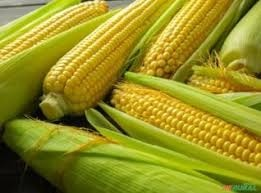

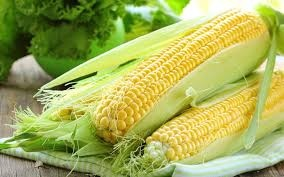

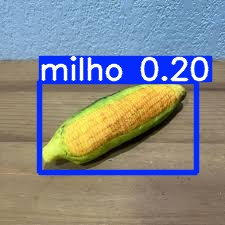

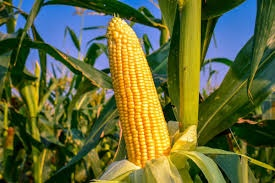

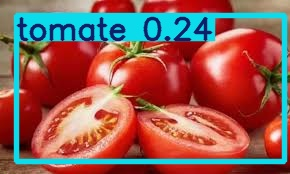

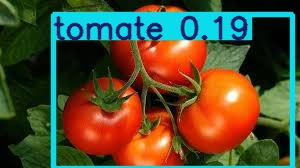

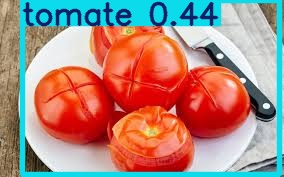

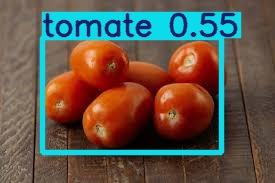

In [28]:
import glob
from IPython.display import Image, display

print("=== Resultados - 30 épocas (conf=0.15) ===")
imgs_30 = glob.glob('runs/detect/teste_30_conf15/*.jpg')
for img in sorted(imgs_30):
    display(Image(filename=img, width=500))

In [13]:
import shutil
import os

# Criar pasta assets no Drive para salvar os prints
assets_path = '/content/drive/MyDrive/pbl_fase6/assets/prints_yolo_custom'
os.makedirs(assets_path, exist_ok=True)

# Copiar imagens de teste processadas para o Drive
for img in glob.glob('runs/detect/teste_30_epocas/*.jpg'):
    shutil.copy(img, assets_path)

for img in glob.glob('runs/detect/teste_60_epocas/*.jpg'):
    shutil.copy(img, assets_path)

print(f'Imagens salvas em: {assets_path}')

Imagens salvas em: /content/drive/MyDrive/pbl_fase6/assets/prints_yolo_custom


## 8. Comparação e Conclusões

### Resultados da Validação
| Modelo | mAP50 | Precisão | Recall |
|--------|-------|----------|--------|
| 30 épocas | 0.465 | 0.288 | 0.625 |
| 60 épocas | 0.354 | 0.355 | 0.479 |

### Resultados dos Testes (conf=0.15)
| Configuração | Detecções corretas | Falsos positivos | Observação |
|--------------|-------------------|------------------|------------|
| 30 épocas | 5/8 | Nenhum | 1 milho + 4 tomates detectados corretamente |
| 60 épocas | 6/8 | Sim | Confundiu milho em imagens de tomate |

### Conclusões
- O modelo de **30 épocas** apresentou maior mAP50 na validação (0.465 vs 0.354)
- O modelo de **30 épocas** foi mais confiável nos testes, sem falsos positivos
- O modelo de **60 épocas** detectou mais imagens, porém com falsos positivos — identificou milho em imagens de tomate
- O **tomate** foi melhor aprendido pelo modelo do que o milho em ambos os treinamentos
- Reduzir o limiar de confiança de 0.25 para 0.15 aumentou as detecções sem comprometer demais a precisão

### Pontos Fortes
- Sistema capaz de detectar tomates com alta consistência (4/4 com conf=0.15)
- Treinamento rápido — menos de 1 hora para os dois modelos completos
- O modelo demonstra potencial real para aplicação no agronegócio

### Limitações
- Dataset reduzido (40 imagens por classe) limita a capacidade de generalização
- Milho foi detectado em apenas 1 de 4 imagens de teste com o modelo de 30 épocas
- Modelo de 60 épocas apresentou falsos positivos com conf=0.15
- Imagens de milho em plantação/campo foram mais difíceis de detectar do que espigas isoladas

## 9. Estrutura dos Arquivos de Resultado

Os resultados dos treinamentos foram salvos em:
- `runs/train/treino_30_epocas/` — pesos e métricas do modelo de 30 épocas
- `runs/train/treino_60_epocas2/` — pesos e métricas do modelo de 60 épocas
- `runs/val/val_30_epocas/` — validação do modelo de 30 épocas
- `runs/val/val_60_epocas/` — validação do modelo de 60 épocas
- `runs/detect/teste_30_conf15/` — teste do modelo de 30 épocas com conf=0.15
- `runs/detect/teste_60_conf15/` — teste do modelo de 60 épocas com conf=0.15
- `assets/prints_yolo_custom/` — prints salvos no Google Drive